# Museums and Zoos/Aquariums by State

Two horizontal bar charts answering: **which states have the most museums, and where are zoos and aquariums concentrated?**

Self-contained — needs only `museums.csv` in the same folder. Run **Kernel → Restart Kernel and Run All Cells**.

## Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("museums.csv", low_memory=False)
df = df.rename(columns={
    "State (Administrative Location)": "state",
    "Museum Type":                     "museum_type",
})
print(f"Loaded {len(df):,} museums across {df['state'].nunique()} states/territories")

Loaded 33,072 museums across 51 states/territories


## Chart 1: Total museums by state

Group by state, count, sort, and plot.

In [2]:
by_state = df["state"].value_counts().sort_values()
by_state.head()  # smallest few

state
DE    132
AK    162
UT    170
NV    174
HI    176
Name: count, dtype: int64

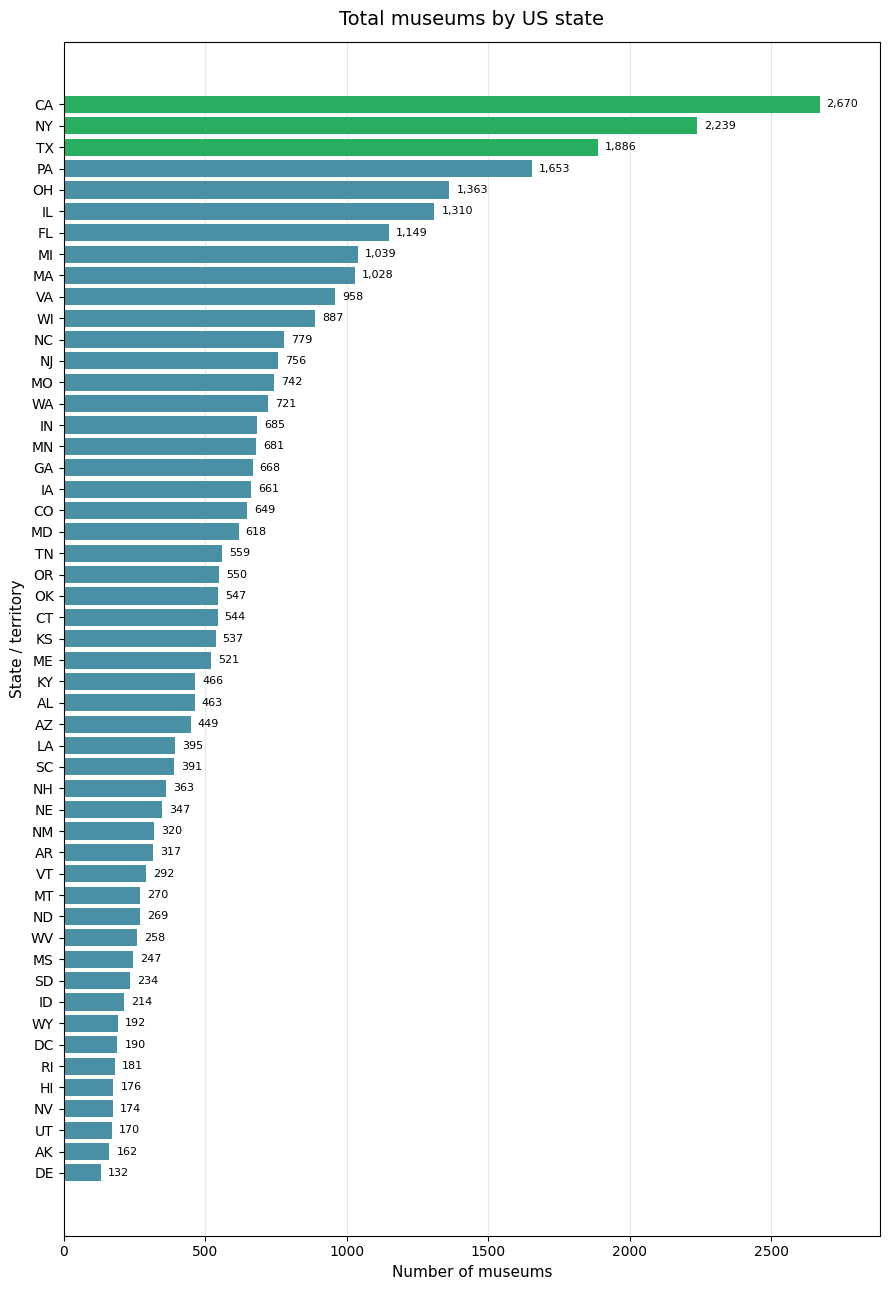

In [3]:
fig, ax = plt.subplots(figsize=(9, 13))

# Highlight the top 3 in green for emphasis
colors = ["#4a90a4"] * len(by_state)
for i in range(len(by_state) - 3, len(by_state)):
    colors[i] = "#27ae60"

bars = ax.barh(by_state.index, by_state.values, color=colors)

ax.set_title("Total museums by US state", fontsize=14, pad=12)
ax.set_xlabel("Number of museums", fontsize=11)
ax.set_ylabel("State / territory", fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

# Value labels at end of each bar
for bar, v in zip(bars, by_state.values):
    ax.text(v + 25, bar.get_y() + bar.get_height() / 2,
            f"{v:,}", va="center", fontsize=8)

ax.set_xlim(0, by_state.max() * 1.08)
plt.tight_layout()
plt.savefig("museums_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

**What the chart shows:** California leads with 2,670 museums, followed by New York (2,239), Texas (1,886), Pennsylvania (1,653), and Ohio (1,363). The distribution closely tracks state population — large-population states have proportionally more museums. The smallest counts (Delaware, Alaska, Utah, Nevada, Hawaii) all sit under 200.

## Chart 2: Zoos and aquariums by state

Filter to the IMLS `ZOO, AQUARIUM, OR WILDLIFE CONSERVATION` category, then group by state.

In [4]:
za_mask = df["museum_type"] == "ZOO, AQUARIUM, OR WILDLIFE CONSERVATION"
za_by_state = df.loc[za_mask, "state"].value_counts().sort_values()
print(f"Total zoo/aquarium/wildlife entries: {za_mask.sum()} across {za_by_state.size} states")
za_by_state.tail(10)

Total zoo/aquarium/wildlife entries: 564 across 51 states


state
MO    14
IL    17
MI    19
OH    19
WI    20
PA    21
NY    38
TX    39
FL    42
CA    47
Name: count, dtype: int64

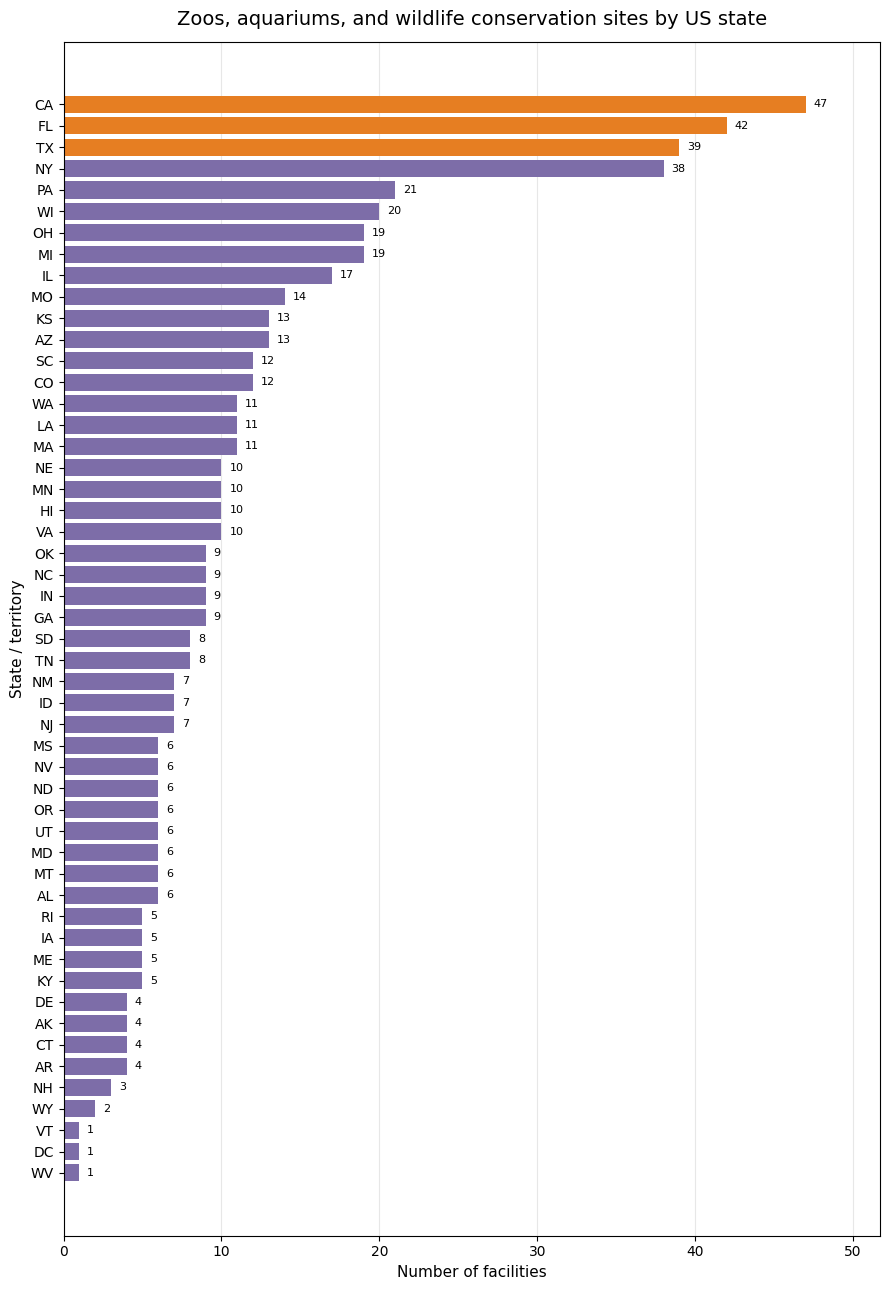

In [5]:
fig, ax = plt.subplots(figsize=(9, 13))

colors = ["#7d6da8"] * len(za_by_state)
for i in range(len(za_by_state) - 3, len(za_by_state)):
    colors[i] = "#e67e22"

bars = ax.barh(za_by_state.index, za_by_state.values, color=colors)

ax.set_title("Zoos, aquariums, and wildlife conservation sites by US state",
             fontsize=14, pad=12)
ax.set_xlabel("Number of facilities", fontsize=11)
ax.set_ylabel("State / territory", fontsize=11)
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)

for bar, v in zip(bars, za_by_state.values):
    ax.text(v + 0.5, bar.get_y() + bar.get_height() / 2,
            str(v), va="center", fontsize=8)

ax.set_xlim(0, za_by_state.max() * 1.10)
plt.tight_layout()
plt.savefig("zoos_aquariums_by_state.png", dpi=150, bbox_inches="tight")
plt.show()

**What the chart shows:** California (47), Florida (42), and Texas (39) are the top three. Florida punches above its weight here — it has fewer total museums than New York or Texas, but more zoo/aquarium facilities than New York, reflecting its tourism-driven attractions and warm climate. The category includes wildlife sanctuaries and ecological preserves alongside true zoos and aquariums (the IMLS bundles them into one type).

## Bonus chart: Top 15 states with zoo/aquarium share highlighted

A single chart that shows where zoos and aquariums fit within each state's broader museum mix.

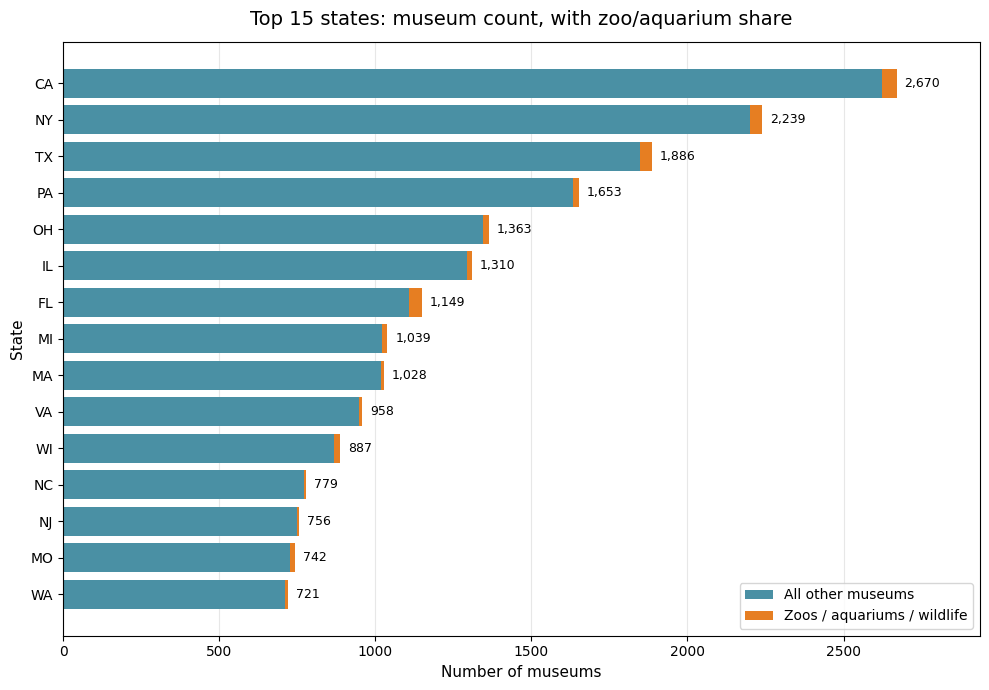

In [6]:
top15 = df["state"].value_counts().head(15).index.tolist()
totals = df[df["state"].isin(top15)]["state"].value_counts().reindex(top15)
zas    = df[df["state"].isin(top15) & za_mask]["state"].value_counts().reindex(top15).fillna(0)
others = totals - zas

order = totals.sort_values().index
others = others.reindex(order)
zas    = zas.reindex(order)

fig, ax = plt.subplots(figsize=(10, 7))
ax.barh(order, others, color="#4a90a4", label="All other museums")
ax.barh(order, zas, left=others, color="#e67e22",
        label="Zoos / aquariums / wildlife")

for i, state in enumerate(order):
    total = others[state] + zas[state]
    ax.text(total + 25, i, f"{int(total):,}", va="center", fontsize=9)

ax.set_title("Top 15 states: museum count, with zoo/aquarium share", fontsize=14, pad=12)
ax.set_xlabel("Number of museums", fontsize=11)
ax.set_ylabel("State", fontsize=11)
ax.legend(loc="lower right")
ax.grid(axis="x", alpha=0.3)
ax.set_axisbelow(True)
ax.set_xlim(0, totals.max() * 1.10)
plt.tight_layout()
plt.savefig("top15_with_zoos.png", dpi=150, bbox_inches="tight")
plt.show()

## What these charts answer

**Where are museums concentrated?** Almost entirely in the most populous states. The top 5 (CA, NY, TX, PA, OH) account for ~30% of all US museums by count. Population is the dominant driver, which is why the [per-capita analysis] in an earlier notebook gives a very different ranking — Vermont and Maine top that list despite having far fewer museums in absolute terms.

**Where are zoos and aquariums concentrated?** Same large states lead, but with one striking exception: Florida ranks #2 for zoos/aquariums while sitting at #6 for total museums. Florida's tourism economy and warm climate support a denser zoo/aquarium footprint than its general museum count would predict.

**Why two separate charts plus the combined view?** The standalone charts show absolute scale for each category. The stacked chart (top 15 states) shows the *relative* share of zoos and aquariums within each state's broader museum landscape, which is much smaller than the bar lengths might suggest — zoos and aquariums are 1–3% of museums in most states.

All three charts are also saved as `.png` files in the notebook's folder for reuse outside this notebook.